Hyperparameter
- ITERS = 10000
- layers = [1,128,128,128,128,8]
- BATCH = 16
- NUM_HIDDEN = 1
- MOMENTUM = 0.8
- learning_rate = 1e-6
- lr_rate = [1e-3, 1e-4, 1e-6]
- lr_boundaries = [5000, 8000]

In [2]:
import time
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal as normal

tf.keras.backend.set_floatx('float64')
tf.compat.v1.enable_eager_execution()

In [3]:
NUM_OF_INTERNAL = 60
TOTAL_T = 60
NUM_HIDDEN = 1
MOMENTUM = 0.8
BATCH = 16
K = 5
ITERS = 10000
SEED = 12345
TEXT = "V_0.925" #change this one

c1 = 100 
c2 = 20
c3 = 50
c4 = 200
c5 = 1000
c6 = 300*1/2

In [4]:
birth =  0.000053
death =  0.000033 

alpha = 0.00135
sigma = 0.06352
beta1 = 0.2812 
beta2 = 0.15838 
beta3 = 0.0388 
delta1 = 0.28505
delta2 = 0.28269
delta3 = 0.14206
gamma = 0.30954
p1 = 0.01845
p2 = 0.1431
mu = 0.0042
sigma1 = 0.09275
sigma2 = 0.03887
sigma3 = 0.07517
sigma4 = 0.06302
sigma5 = 0.07878
sigma6 = 0.06123
sigma7 = 0.0611
sigma8 = 0.06199

N = 6629870
S0 = (3674149/N + 2845438/N)* 0.075
V0 = (3674149/N + 2845438/N)* 0.925
E0 = 67789/N
I10 = 12113/N
I20 = 498/N
I30 = 96/N
R0 = 28911/N
D0 = 876/N

init = [S0, V0, E0, I10, I20, I30, R0, D0]

In [5]:
k0 = 0.006
k1 = -0.1341

def p1fn(alpha):
    return k0 + k1 * alpha

In [6]:
class Solver(object):

    def __init__(self, seed_var):
        self.valid_size = BATCH
        self.batch_size = BATCH
        
        self.num_iterations = ITERS
        self.print_frequency = 100
        self.lr_values = [1e-3, 1e-4, 1e-6]
        self.lr_boundaries = [5000, 8000]
        self.config = Config()

        self.model = WholeNet(seed_var)
        lr_schedule = tf.keras.optimizers.schedules.PiecewiseConstantDecay(self.lr_boundaries, self.lr_values)
        self.optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule, epsilon=1e-7)

    def train(self):
        """Training the model"""
        start_time = time.time()
        training_history = []
        control_output = [] 
        
        dW = self.config.sample(self.valid_size)
        valid_data = dW
        for step in range(self.num_iterations+1):
            if step % self.print_frequency == 0:
                cost, row_out0 = self.model(valid_data, training=True)
                elapsed_time = time.time() - start_time
                training_history.append([step, cost, elapsed_time])
                print("step: %5u, Cost: %.4e, elapsed time: %3u" % (step, cost, elapsed_time))
            if step == self.num_iterations:
                cost1, row_out1 = self.model(valid_data, training=True)
                row_output = row_out1.numpy()
                control_output.append(row_output)
            self.train_step(self.config.sample(self.batch_size))
        self.training_history = training_history
        self.control_output = control_output

    @tf.function
    def train_step(self, train_data):
        """Updating the gradients"""
        with tf.GradientTape(persistent=True) as tape:
            loss = self.model(train_data, training = True)
        grad = tape.gradient(loss, self.model.trainable_variables)
        del tape
        self.optimizer.apply_gradients(zip(grad, self.model.trainable_variables))

In [7]:
class WholeNet(tf.keras.Model):
    """Building the neural network architecture"""
    def __init__(self,seed_var):
        super(WholeNet, self).__init__()
        self.config = Config()
        self.subnet = [FNNet(seed_var) for _ in range(self.config.num_time_interval)]

    def call(self, dw, training):
        x_init = tf.ones([1, self.config.dim_x], dtype=tf.dtypes.float64) * init
        time_stamp = np.arange(0, self.config.num_time_interval) * self.config.delta_t
        all_ones = tf.ones([tf.shape(dw)[0], 1], dtype=tf.dtypes.float64)

        # initial state
        x = tf.matmul(all_ones, x_init)

        # initial cost functional
        l = 0.0 
        u_set = []
        for t in range(0, self.config.num_time_interval):
            u = self.subnet[t](x, training)
            u_set.append(tf.stack([u], axis=0))   
            l = l + self.config.f_fn(time_stamp[t], x, u) * self.config.delta_t
            x = x + self.config.b_fn(time_stamp[t], x, u) * self.config.delta_t + self.config.sigma_fn(time_stamp[t], x, u) * dw[:,:,  t]

        # control variable
        control_u = tf.stack(u_set, axis=0)
        row_ave2 = tf.reduce_mean(control_u, axis=2)
        row_out1 = tf.squeeze(row_ave2, axis=[1,2])
        #print("u timepath2", row_ave2)
        
        # terminal condition
        l = l + self.config.h_fn(self.config.total_time, x)
        cost = tf.reduce_mean(l) 
        return cost, row_out1


In [8]:
class FNNet(tf.keras.Model):
    def __init__(self, seed_var):
        super(FNNet, self).__init__()
        self.config = Config()

        tf.random.set_seed(seed_var)
        np.random.seed(seed_var)
        
        num_hiddens = [self.config.dim_x + NUM_HIDDEN, self.config.dim_x + NUM_HIDDEN, self.config.dim_x + NUM_HIDDEN]
        self.bn_layers = [
            tf.keras.layers.BatchNormalization(
                momentum=MOMENTUM,
                epsilon=1e-6,
                beta_initializer=tf.random_normal_initializer(0.0, stddev=0.1,seed=seed_var),
                gamma_initializer=tf.random_uniform_initializer(0.1, 0.5,seed=seed_var)
            )
            for _ in range(len(num_hiddens) + 2)]
        self.dense_layers = [tf.keras.layers.Dense(num_hiddens[i],
                                                   use_bias=True,
                                                   activation='tanh')
                             for i in range(len(num_hiddens))]
        
        # final output should be gradient of size dim_u
        self.dense_layers.append(tf.keras.layers.Dense(self.config.dim_u, activation='sigmoid'))

    def call(self, x, training):
        x = self.bn_layers[0](x, training)
        for i in range(len(self.dense_layers) - 1):
            x = self.dense_layers[i](x)
            x = self.bn_layers[i+1](x, training)
            x = tf.nn.tanh(x)
        x = self.dense_layers[-1](x)
        x = self.bn_layers[-1](x, training)
        return tf.nn.tanh(x) * 0.012 + 0.016

In [9]:
class Config(object):
    """function config"""
    def __init__(self):
        super(Config, self).__init__()
        self.dim_x = 8
        self.dim_u = 1
        self.num_time_interval = NUM_OF_INTERNAL
        self.total_time = TOTAL_T
        self.delta_t = (self.total_time + 0.0) / self.num_time_interval
        self.sqrth = np.sqrt(self.delta_t)
        self.t_stamp = np.arange(0, self.num_time_interval) * self.delta_t

    # sample function
    def sample(self, num_sample):
        dw_sample = normal.rvs(size=[num_sample, self.dim_x, self.num_time_interval]) * self.sqrth
        return dw_sample

    # cost functional integral item
    def f_fn(self, t, x, u):
        tensors = []
        for i in range(BATCH):
            S = x[i][0]
            V = x[i][1]
            E = x[i][2]
            I1 = x[i][3]
            I2 = x[i][4]
            I3 = x[i][5]
            R = x[i][6]
            D = x[i][7]
            alpha = u[i][0]  
            cost = (c1 * alpha ** 2 + c2 * E + (c3*I1 + c4*I2 + c5*I3) + c6 * (tf.maximum(tf.cast(0, tf.float64), 1-(S+V+R)))) 
            combined_cost = tf.stack([cost], axis=0)
            tensors.append(combined_cost)
            combined_tensor = tf.stack(tensors, axis=0)
        return tf.reduce_sum(combined_tensor, 1, keepdims=True)

    # cost fuctional terminal function
    def h_fn(self, t, x):
        return 0

    def b_fn(self, t, x, u):
        tensors = []
        for i in range(BATCH):
            S = x[i][0]
            V = x[i][1]
            E = x[i][2]
            I1 = x[i][3]
            I2 = x[i][4]
            I3 = x[i][5]
            R = x[i][6]
            D = x[i][7]
            alpha = u[i][0]
            dS = birth + (- ( beta1 * I1 + beta2 * I2 + beta3 * I3) * S  - alpha * S) - death*S
            dV = (alpha * S - sigma * (beta1 * I1 + beta2 * I2 + beta3 * I3) * V) - death*V
            dE = ((beta1 * I1 + beta2 * I2 + beta3 * I3) * S  + sigma * (beta1 * I1 + beta2 * I2 + beta3 * I3) * V - gamma * E) - death*E
            dI1 = (gamma * E - (delta1 + p1fn(alpha)) * I1) - death*I1
            dI2 = (p1fn(alpha) * I1 - (delta2 + p2) * I2) - death*I2
            dI3 = (p2 * I2 - (delta3 + mu) * I3) - death*I3
            dR = (delta1 * I1+ delta2 * I2 + delta3 * I3) - death*R
            dD = (mu * I3) 
            combined_ten = tf.stack([dS, dV,dE,dI1,dI2,dI3,dR,dD], axis=0)
            tensors.append(combined_ten)
            combined_tensor = tf.stack(tensors, axis=0)
        return combined_tensor

    def sigma_fn(self, t, x, u):
        #return x
        tensors = []
        for i in range(BATCH):
            S = x[i][0]
            V = x[i][1]
            E = x[i][2]
            I1 = x[i][3]
            I2 = x[i][4]
            I3 = x[i][5]
            R = x[i][6]
            D = x[i][7]
            sig_S = sigma1*S
            sig_V = sigma2*V
            sig_E = sigma3*E
            sig_I1 = sigma4*I1
            sig_I2 = sigma5*I2
            sig_I3 = sigma6*I3
            sig_R = sigma7*R
            sig_D = sigma8*D
            combined_sig = tf.stack([sig_S, sig_V,sig_E,sig_I1,sig_I2,sig_I3,sig_R,sig_D], axis=0)
            tensors.append(combined_sig)
            combined_tensor = tf.stack(tensors, axis=0)
        return combined_tensor

In [10]:
output_table = np.zeros((int(round(ITERS) / 100) + 1, 2 + int(round(K))))
control_outs_table = np.zeros((int(round(K)), TOTAL_T))


def main():
    solver = Solver(seed_var=SEED)
    print('Training time %3u:' % (1))
    solver.train()
    data = np.array(solver.training_history)
    control_output_data = np.array(solver.control_output)
    k = K
    
    output = np.zeros((len(data[:, 0]), 2 + k))
    output[:, 0] = data[:, 0]
    output[:, 1] = data[:, 2]
    output[:, 2] = data[:, 1]
    output_table[:, 0] = data[:, 0]
    output_table[:, 1] = data[:, 2]
    output_table[:, 2] = data[:, 1]

    
    control_outs = np.zeros((k, len(control_output_data[0])))
    control_outs[0] = control_output_data[0]

    
    for i in range(k - 1):
        print('Training time %3u:' % (i + 2))
        solver = Solver(seed_var=12345+1+i)  
        solver.train()
        data = np.array(solver.training_history)
        control_output_data = np.array(solver.control_output)
        output[:, 3 + i] = data[:, 1]
        output_table[:, 3 + i] = data[:, 1]
        control_outs[1+i] = control_output_data[0]
        control_outs_table[1+i] = control_output_data[0]

    a = ['%d', '%.5e']
    for _ in range(k):
        a.append('%.5e')
    
    con_format = ['%.5e']
    for _ in range(len(control_output_data[0])-1):
        con_format.append('%.5e')
        
    np.savetxt('./Sto_control_Opt_Vacc_'+str(TEXT)+'.csv', control_outs, fmt=con_format, delimiter=',')
    np.savetxt('./Sto_control_Loss_'+str(TEXT)+'.csv', output, fmt=a, delimiter=',')
    print('Solving is done!')

if __name__ == '__main__':
    main()


2024-10-02 05:43:42.859215: I tensorflow/compiler/jit/xla_cpu_device.cc:41] Not creating XLA devices, tf_xla_enable_xla_devices not set
2024-10-02 05:43:42.859628: I tensorflow/core/platform/cpu_feature_guard.cc:142] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.2
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


Training time   1:
step:     0, Cost: 5.8014e+02, elapsed time:   4


2024-10-02 05:48:53.657020: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:116] None of the MLIR optimization passes are enabled (registered 2)


step:   100, Cost: 5.7972e+02, elapsed time: 500
step:   200, Cost: 5.7934e+02, elapsed time: 515
step:   300, Cost: 5.7883e+02, elapsed time: 531
step:   400, Cost: 5.7832e+02, elapsed time: 546
step:   500, Cost: 5.7806e+02, elapsed time: 562
step:   600, Cost: 5.7763e+02, elapsed time: 577
step:   700, Cost: 5.7744e+02, elapsed time: 593
step:   800, Cost: 5.7708e+02, elapsed time: 608
step:   900, Cost: 5.7680e+02, elapsed time: 625
step:  1000, Cost: 5.7643e+02, elapsed time: 641
step:  1100, Cost: 5.7626e+02, elapsed time: 657
step:  1200, Cost: 5.7605e+02, elapsed time: 673
step:  1300, Cost: 5.7579e+02, elapsed time: 689
step:  1400, Cost: 5.7561e+02, elapsed time: 705
step:  1500, Cost: 5.7541e+02, elapsed time: 721
step:  1600, Cost: 5.7534e+02, elapsed time: 737
step:  1700, Cost: 5.7527e+02, elapsed time: 753
step:  1800, Cost: 5.7515e+02, elapsed time: 769
step:  1900, Cost: 5.7505e+02, elapsed time: 785
step:  2000, Cost: 5.7494e+02, elapsed time: 801
step:  2100, Cost: 5

In [11]:
loss_val = output_table[:, 2]
for i in range(K-1):
    loss_val = loss_val + output_table[:, i+3]
average_cost = loss_val/K
print(average_cost)

[649.35876102 649.47781169 648.79742748 648.48710901 647.69194711
 647.2330963  646.61840478 646.16840126 645.80812155 645.462583
 645.15781337 644.96030988 644.75090237 644.68296083 644.44795413
 644.27948502 644.20926427 644.10183888 643.96402404 643.93769489
 643.94418498 643.76355864 643.73924685 643.73543562 643.67423898
 643.61565938 643.52910775 643.44499345 643.38365292 643.396754
 643.32898568 643.32564687 643.26833314 643.25345684 643.22475054
 643.19322918 643.15175932 643.13801415 643.10248642 643.0914387
 643.08627393 643.06320331 643.05130172 643.02560317 642.97489249
 642.97641735 642.95044593 642.9376243  642.92876562 642.91641636
 642.8955286  642.89154465 642.88929142 642.88870413 642.88447559
 642.88345143 642.88546203 642.88705425 642.88803124 642.88908569
 642.88712317 642.8880317  642.88652314 642.8875345  642.88722316
 642.88528916 642.88498787 642.88156161 642.88180738 642.88161314
 642.88200988 642.88303008 642.877696   642.87547889 642.87605883
 642.87606235 6

In [12]:
print(output_table)
#cost1 = output_table[:, 2]
#cost2 = output_table[:, 3]
#cost3 = output_table[:, 4]

# Compute averages
#average_cost = (cost1 + cost2+ cost3) / 3
#print(average_cost)

[[0.00000000e+00 4.54289389e+00 5.80144939e+02 4.36202181e+02
  6.08203237e+02 8.26795049e+02 7.95448398e+02]
 [1.00000000e+02 5.00396288e+02 5.79719969e+02 4.36648393e+02
  6.09295019e+02 8.26329005e+02 7.95396672e+02]
 [2.00000000e+02 5.15647154e+02 5.79341526e+02 4.34679493e+02
  6.08796381e+02 8.25749750e+02 7.95419988e+02]
 [3.00000000e+02 5.31097485e+02 5.78833288e+02 4.35293385e+02
  6.07653940e+02 8.25161321e+02 7.95493611e+02]
 [4.00000000e+02 5.46559728e+02 5.78318571e+02 4.34807438e+02
  6.05394711e+02 8.24493766e+02 7.95445250e+02]
 [5.00000000e+02 5.62052959e+02 5.78061331e+02 4.33802982e+02
  6.05374566e+02 8.23435298e+02 7.95491304e+02]
 [6.00000000e+02 5.77559361e+02 5.77634867e+02 4.32761309e+02
  6.04021027e+02 8.23163302e+02 7.95511519e+02]
 [7.00000000e+02 5.93103205e+02 5.77435505e+02 4.31841056e+02
  6.03716906e+02 8.22366379e+02 7.95482160e+02]
 [8.00000000e+02 6.08775038e+02 5.77075476e+02 4.31536803e+02
  6.03238978e+02 8.21886091e+02 7.95303260e+02]
 [9.000000

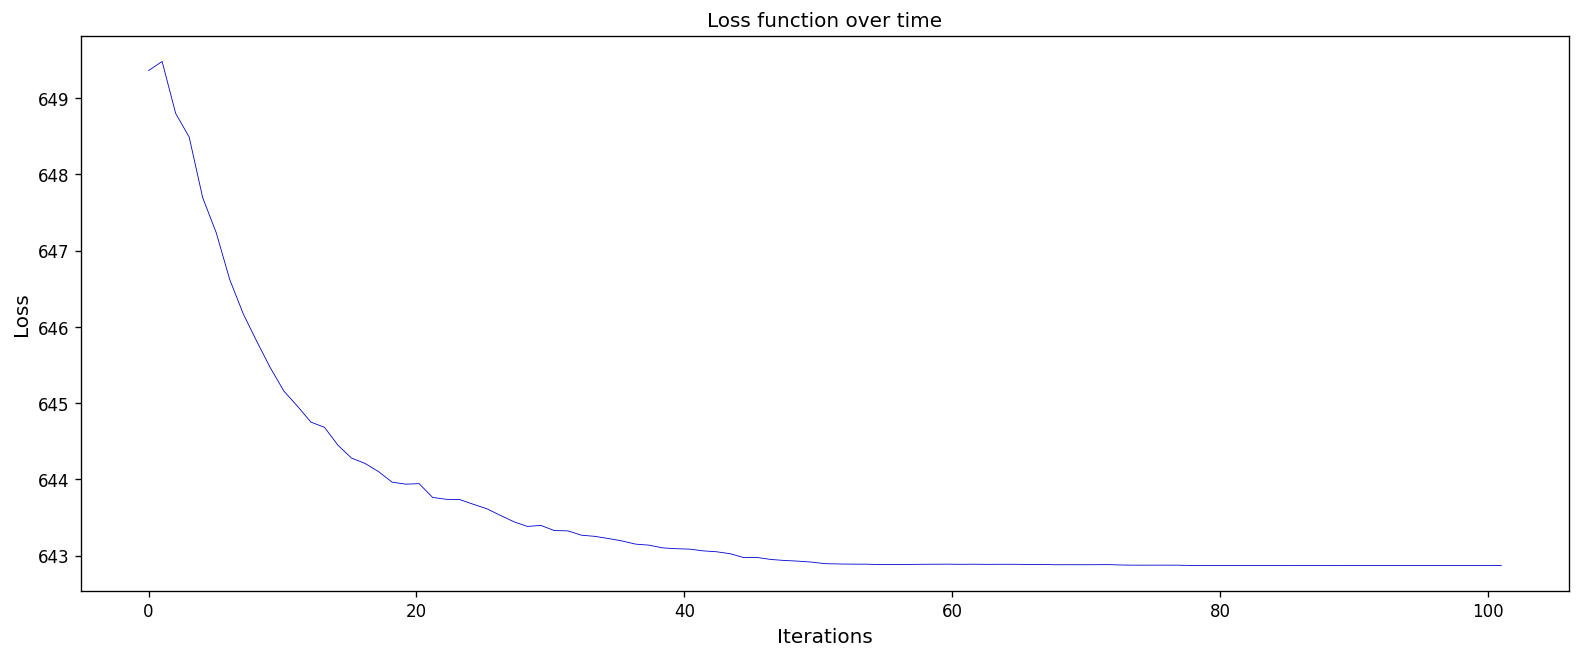

In [13]:
t = np.linspace(0, len(average_cost), len(average_cost))
fig, ax0 = plt.subplots(1, 1, figsize =(16,6), dpi = 120, sharey = True)
ax0.plot(t, average_cost, lw = 0.5, color = 'mediumblue', label = 'average_cost')
ax0.set_xlabel('Iterations', fontsize = 12)
ax0.set_ylabel('Loss', fontsize = 12)
ax0.set_title('Loss function over time', fontsize = 12)
plt.savefig('Loss_'+str(TEXT)+'.png')

[0.00453915 0.0045525  0.00458183 0.00459777 0.00464453 0.00460511
 0.00461687 0.00461016 0.00460814 0.00456604 0.00455588 0.00462614
 0.00460591 0.00461711 0.00463163 0.00463762 0.00468302 0.0046321
 0.00462987 0.00475364 0.00467069 0.00478089 0.00464692 0.00464085
 0.00478014 0.00477542 0.00464175 0.0046792  0.00475562 0.00482357
 0.00506683 0.00500315 0.00478959 0.00492934 0.00493286 0.00458835
 0.00466549 0.00480002 0.00473062 0.00452996 0.00452857 0.00450775
 0.00448103 0.00447813 0.00444854 0.00441979 0.00439    0.00438039
 0.00434998 0.00433624 0.00432254 0.00430444 0.0042817  0.00427194
 0.00426049 0.00425623 0.00425201 0.0042521  0.00425254 0.00424888]


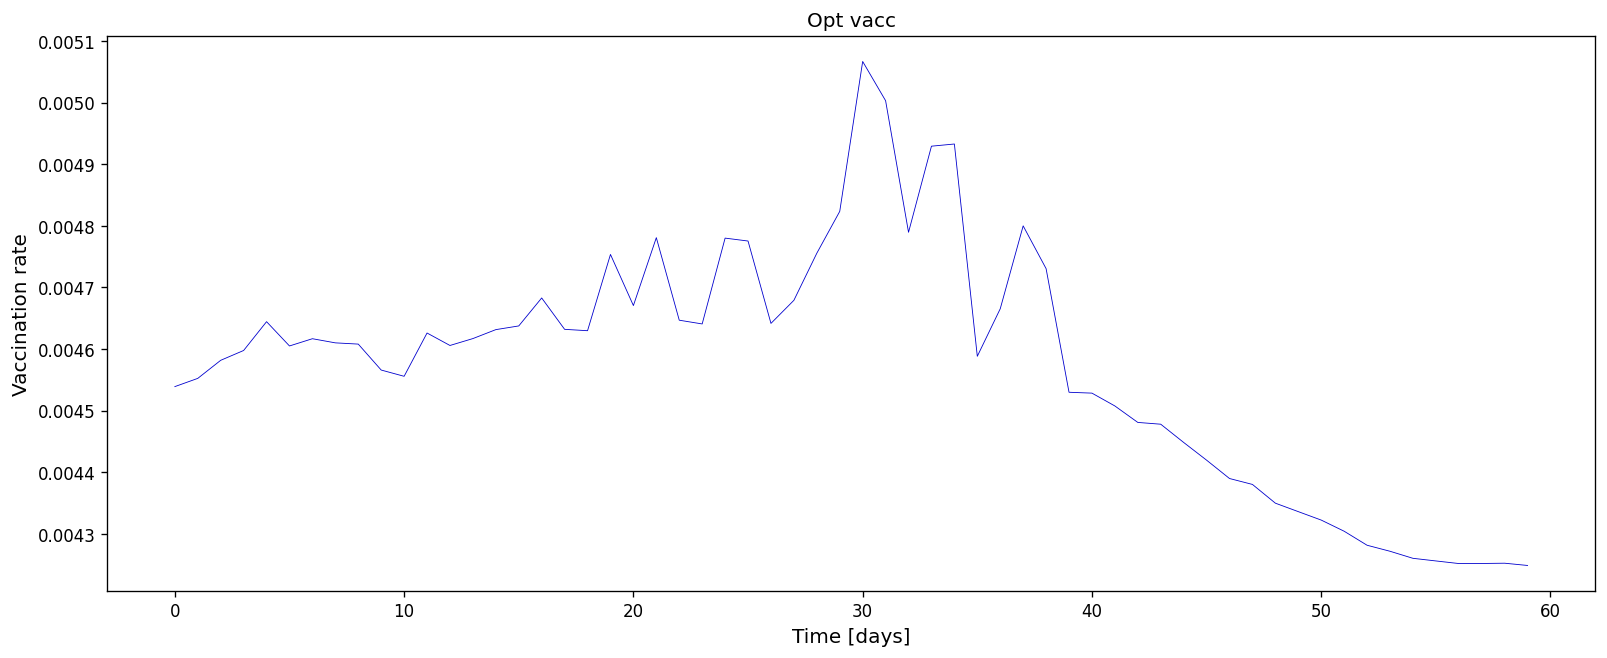

In [14]:
print(control_outs_table[1:2,:].flatten())
t = np.linspace(0, len(control_outs_table[1:2,:].flatten()),len(control_outs_table[1:2,:].flatten()))
fig, ax0 = plt.subplots(1, 1, figsize =(16,6), dpi = 120, sharey = True)
ax0.plot(control_outs_table[1:2,:].flatten(), lw = 0.5, color = 'mediumblue', label = 'average_cost')
ax0.set_xlabel('Time [days]', fontsize = 12)
ax0.set_ylabel('Vaccination rate', fontsize = 12)
ax0.set_title('Opt vacc', fontsize = 12)
plt.savefig('Opt vacc_'+str(TEXT)+'.png')